# 02 · Clean & characterize the data

Notebook 01 was a *first look*. Before any quant trusts a dataset, they do two unglamorous-but-essential jobs:

1. **Data quality audit & cleaning** — missing values, duplicate timestamps, time-gaps, degenerate columns, infinities.
2. **Characterize the data the way *finance* demands** — stationarity, fat tails, volatility clustering. These are different from generic DS because price data breaks the assumptions most textbooks make.

Why this matters: nearly every false 'edge' a beginner finds traces back to skipping one of these steps.

## Block 0 · Setup + load

In [1]:
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
try:
    import seaborn as sns; sns.set_theme(style='whitegrid'); HAVE_SNS=True
except ImportError:
    HAVE_SNS=False

ROOT = Path.cwd()
while not (ROOT/'CLAUDE.md').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
DATA = ROOT/'data'

feat  = DATA/'features'/'features_btcusd_M3.parquet'
label = DATA/'labels'/'labels_btcusd_M3.parquet'
bars_glob = str(DATA/'processed'/'bars_btcusd_M3_*.parquet')

# Join features + labels + (bar spread/tick_count) on ts.
df = duckdb.sql(f"""
    SELECT f.*, l.fwd_ret_5, l.fwd_ret_10, l.fwd_ret_20, l.fwd_ret_60, l.hit_tp_before_sl,
           b.spread_mean, b.tick_count
    FROM '{feat}' f
    JOIN '{label}' l USING (ts)
    LEFT JOIN (SELECT ts, spread_mean, tick_count FROM read_parquet('{bars_glob}')) b USING (ts)
    ORDER BY f.ts
""").df()
print(f'{len(df):,} rows x {df.shape[1]} cols   {df.ts.min()} -> {df.ts.max()}')

424,729 rows x 50 cols   2024-01-01 00:00:00 -> 2026-06-09 23:57:00


## Block 1 · Data quality audit
Five checks, in order of how often they bite people.

In [2]:
# (a) Missing values — count + % per column, only columns that actually have some.
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
miss = pd.DataFrame({'n_missing': na, 'pct': (100*na/len(df)).round(3)})
print('Columns with missing values:')
print(miss.to_string() if len(miss) else '  (none)')

Columns with missing values:
                  n_missing    pct
dist_vah                480  0.113
dist_val                480  0.113
dist_poc                480  0.113
atr_pct                 479  0.113
cloud_thickness          77  0.018
fwd_ret_60               60  0.014
dist_kijun               25  0.006
fwd_ret_20               20  0.005
fwd_ret_10               10  0.002
dist_tenkan               8  0.002
rsi_7_accel               7  0.002
rsi_14_accel              7  0.002
rsi_21_accel              7  0.002
adx_accel                 6  0.001
fwd_ret_5                 5  0.001
rsi_7_slope               4  0.001
rsi_14_slope              4  0.001
rsi_21_slope              4  0.001
ema_12_slope              3  0.001
adx_slope                 3  0.001
atr_slope                 3  0.001
ema_25_slope              3  0.001
ema_200_slope             3  0.001
ema_100_slope             3  0.001
ema_75_slope              3  0.001
ema_50_slope              3  0.001
hit_tp_before_sl          

In [3]:
# (b) Duplicate timestamps — there must be exactly ONE row per bar.
dups = df.ts.duplicated().sum()
print(f'duplicate timestamps: {dups}')

# (c) Infinite values — sneak in from divisions (e.g. slopes, ratios).
num = df.select_dtypes('number')
infs = np.isinf(num.to_numpy()).sum()
print(f'infinite values across numeric cols: {infs}')

# (d) Degenerate (constant / near-zero-variance) columns — carry no information.
nunique = num.nunique()
degenerate = nunique[nunique <= 1]
print(f'constant columns: {list(degenerate.index) or "(none)"}')

duplicate timestamps: 0
infinite values across numeric cols: 0


constant columns: (none)


median gap: 3.0 min (expected 3.0)
rows after a gap > 4.5 min: 51  (0.01%)

largest gaps (hours):
216594    48.05
229067    24.05
47013      6.95
56028      6.00
333070     5.55


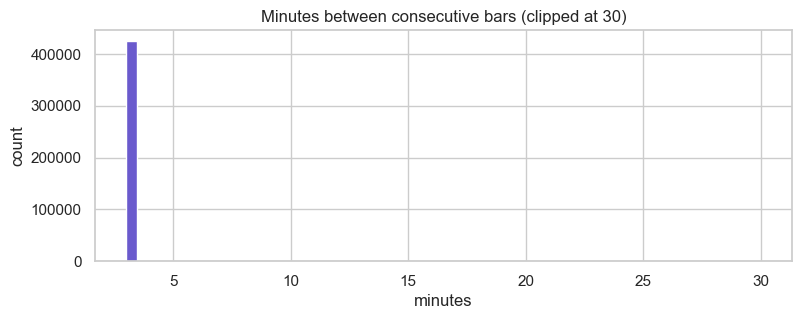

In [4]:
# (e) Time-gaps — M3 bars should be 3 minutes apart. Gaps = weekends / market closes / missing data.
dt = df.ts.diff().dt.total_seconds() / 60.0   # minutes between consecutive bars
expected = 3.0
gaps = dt[dt > expected * 1.5]                 # anything notably bigger than one bar
print(f'median gap: {dt.median():.1f} min (expected {expected})')
print(f'rows after a gap > {expected*1.5} min: {len(gaps):,}  ({100*len(gaps)/len(df):.2f}%)')
print('\nlargest gaps (hours):')
print((gaps.sort_values(ascending=False).head(5) / 60).round(2).to_string())

fig, ax = plt.subplots(figsize=(9,3))
ax.hist(np.clip(dt.dropna(), 0, 30), bins=60, color='slateblue')
ax.set_title('Minutes between consecutive bars (clipped at 30)')
ax.set_xlabel('minutes'); ax.set_ylabel('count'); plt.show()

**Read the gaps result carefully.** Gaps are *expected* here (crypto trades ~24/7 but this feed still has weekend thinning and occasional missing days — see the project's data-quirks notes). The lesson: gaps mean **you cannot assume row `t-1` is 3 minutes before row `t`**. Any feature that looks back a fixed number of *bars* is fine; anything that assumes fixed *wall-clock* spacing is a bug.

## Block 2 · Cleaning decisions (and the lookahead trap)
Cleaning is **decisions**, not a button. The single most important rule here:

> **Never forward-fill or interpolate features using future information.** Filling a missing value at bar `t` with data from `t+1` leaks the future → fake edge. When in doubt, *drop the row*, don't invent a value.

The leading-NaN values you saw (EMAs, ADX) are warm-up periods — the indicator needs N bars before it's valid. The correct fix is to drop the warm-up rows, not fill them.

In [5]:
# Columns we'll actually use downstream. Drop rows missing ANY of them; report the cost.
use_cols = ['close','rsi_14','adx','di_plus','di_minus','di_spread','atr','atr_pct',
            'ema_50_slope','dist_poc','hour','fwd_ret_10','spread_mean']
before = len(df)
clean = df.dropna(subset=use_cols).copy()
print(f'dropped {before-len(clean):,} rows ({100*(before-len(clean))/before:.2f}%) -> {len(clean):,} clean rows')

# Outlier handling = a DECISION. For volatility (atr) we KEEP fat tails (the violent bars are real & important).
# For a feature feeding a linear model you might WINSORIZE (clip extremes). Here's the clip move, shown not applied:
lo, hi = clean['di_spread'].quantile([0.001, 0.999])
clean['di_spread_winsor'] = clean['di_spread'].clip(lo, hi)
print(f'\nexample winsorize di_spread to [{lo:.2f}, {hi:.2f}] (0.1%-99.9%) -> new col di_spread_winsor')
print('rule of thumb: winsorize inputs to linear models; keep raw tails when the tail IS the signal.')

dropped 490 rows (0.12%) -> 424,239 clean rows

example winsorize di_spread to [-44.63, 44.99] (0.1%-99.9%) -> new col di_spread_winsor
rule of thumb: winsorize inputs to linear models; keep raw tails when the tail IS the signal.


## Block 3 · Characterize like a quant — stationarity & fat tails

**Prices are non-stationary** (they trend/wander — the mean isn't constant), which breaks correlation, regression, most ML. **Returns are (roughly) stationary.** This is *the* reason quants model returns, not prices. Let's prove it instead of taking it on faith.

In [6]:
from statsmodels.tsa.stattools import adfuller

# Use a contiguous recent slice so the ADF test is fast and the 'time order' is real.
sl = clean.tail(8000)
price = sl['close'].to_numpy()
ret   = np.diff(np.log(price))           # log returns = stationary candidate

def adf_report(x, name):
    stat, p, *_ = adfuller(x, autolag='AIC')
    verdict = 'STATIONARY (reject unit root)' if p < 0.05 else 'NON-stationary (cannot reject)'
    print(f'{name:18} ADF stat={stat:8.3f}  p={p:.4g}  -> {verdict}')

adf_report(price, 'price (close)')
adf_report(ret,   'log returns')
print('\nExpect: price NON-stationary, returns stationary. This is why we model returns.')

price (close)      ADF stat=  -0.541  p=0.8838  -> NON-stationary (cannot reject)


log returns        ADF stat= -31.307  p=0  -> STATIONARY (reject unit root)

Expect: price NON-stationary, returns stationary. This is why we model returns.


skew     = -0.276   (0 = symmetric)
kurtosis = 26.470  (0 = normal; >0 = fat tails)
Jarque-Bera p = 0  -> NOT normal


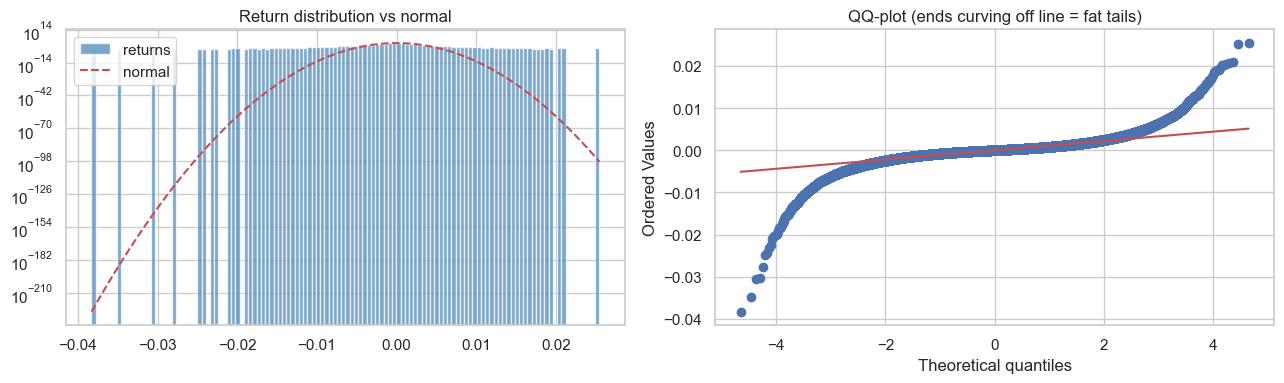

In [7]:
# Fat tails: financial returns are NOT normal — extreme moves happen far more often than a bell curve predicts.
r = np.diff(np.log(clean['close'].to_numpy()))
r = r[np.isfinite(r)]

print(f'skew     = {stats.skew(r):.3f}   (0 = symmetric)')
print(f'kurtosis = {stats.kurtosis(r):.3f}  (0 = normal; >0 = fat tails)')
jb_stat, jb_p = stats.jarque_bera(r)[:2]
print(f'Jarque-Bera p = {jb_p:.3g}  -> {"NOT normal" if jb_p<0.05 else "normal-ish"}')

fig, axes = plt.subplots(1, 2, figsize=(13,4))
# (left) histogram vs a normal curve with the same mean/std
axes[0].hist(r, bins=120, density=True, alpha=0.7, color='steelblue', label='returns')
xs = np.linspace(r.min(), r.max(), 200)
axes[0].plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), 'r--', label='normal')
axes[0].set_title('Return distribution vs normal'); axes[0].legend(); axes[0].set_yscale('log')
# (right) QQ-plot: points leaving the line at the ends = fat tails
stats.probplot(r, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot (ends curving off line = fat tails)')
plt.tight_layout(); plt.show()

## Block 4 · Autocorrelation & volatility clustering
Two classic 'stylized facts' of markets:
- **Returns have ~zero autocorrelation** → you can't predict direction from recent direction alone (markets are *mostly* efficient). If you saw strong return autocorrelation, you'd suspect a data bug.
- **Absolute returns ARE autocorrelated** → volatility clusters (calm follows calm, chaos follows chaos). This is real and exploitable for *sizing/timing*, even when direction isn't predictable.

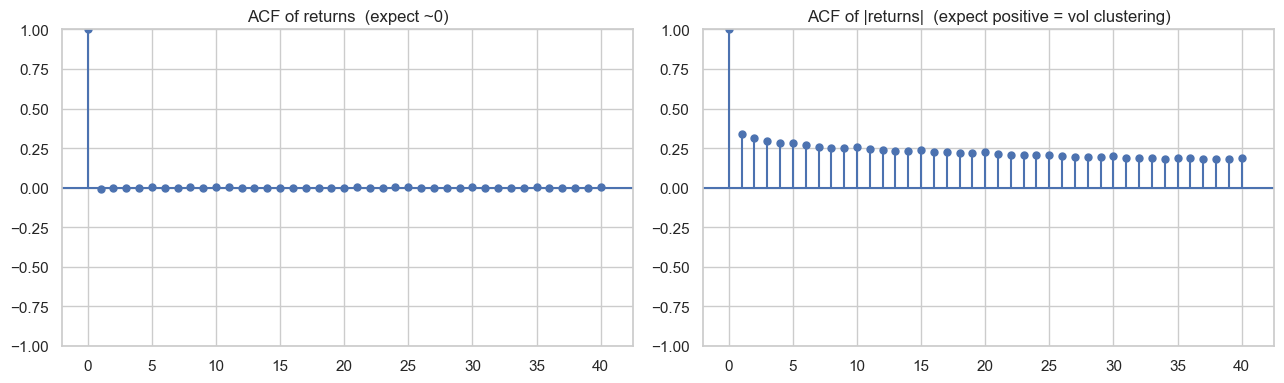

In [8]:
from statsmodels.graphics.tsaplots import plot_acf
rr = pd.Series(r)
fig, axes = plt.subplots(1, 2, figsize=(13,4))
plot_acf(rr,        lags=40, ax=axes[0], title='ACF of returns  (expect ~0)')
plot_acf(rr.abs(),  lags=40, ax=axes[1], title='ACF of |returns|  (expect positive = vol clustering)')
plt.tight_layout(); plt.show()

## 🎯 Your turn
1. Re-run Block 3's ADF test on `atr` and on `rsi_14`. Are indicators stationary? (Bounded oscillators like RSI usually are; raw price-derived ones may not be.)
2. In Block 1(e), change the gap threshold and find: what's the single biggest time-gap, and what date does it fall on? (Cross-check against the BTCUSD data-quirks note about missing 2025 days.)
3. The return distribution had kurtosis ≫ 0. Roughly what fraction of moves are beyond 3 standard deviations? Compare to the 0.3% a normal distribution predicts. (Hint: `(np.abs(r) > 3*r.std()).mean()`.)
4. Why is it *dangerous* to standardize (z-score) a non-stationary feature using the whole dataset's mean/std? (Think about what the mean of a trending series even means.)